In [15]:
import sys
sys.path.insert(0, '..')

import random
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from skimage.morphology import dilation, footprint_rectangle
from skimage.segmentation import watershed
from PIL import Image

DATA_DIR  = Path('data-science-bowl-2018')
TRAIN_DIR = DATA_DIR / 'stage1_train'

random.seed(7)
all_ids = sorted(p.name for p in TRAIN_DIR.iterdir())
print(f'Total train images: {len(all_ids)}')

Total train images: 670


## 1. `_pad32` — Pad images to multiples of 32

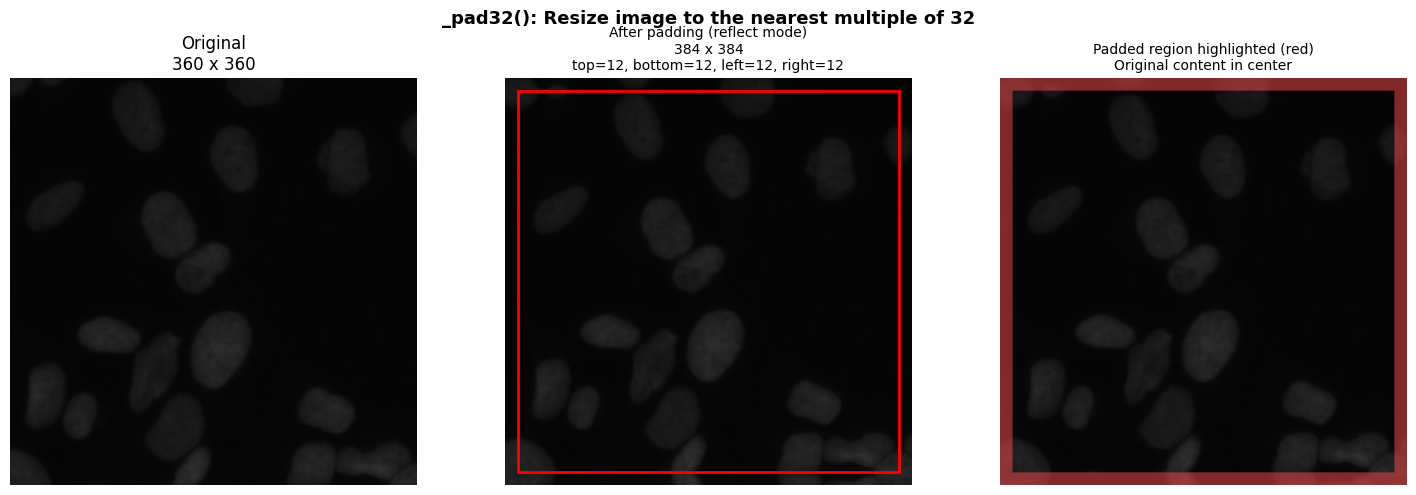

Image ID      : 02903040e19ddf92f452907644ad3822918f54af41dd85e5a3fe3e1b6d6f9339
Original size : 360 x 360
Padded size   : 384 x 384  (384//32=12, 384//32=12)
Padding added : top=12, bottom=12, left=12, right=12


In [16]:
def _pad32(img):
    h, w   = img.shape[:2]
    pad_h  = (32 - h % 32) % 32
    pad_w  = (32 - w % 32) % 32
    t = pad_h // 2;  b = pad_h - t
    l = pad_w // 2;  r = pad_w - l
    if img.ndim == 3:
        padded = np.pad(img, ((t, b), (l, r), (0, 0)), mode='reflect')
    else:
        padded = np.pad(img, ((t, b), (l, r)), mode='reflect')
    return padded, (t, b, l, r)

# Find an image whose width is NOT a multiple of 32
non32_ids = []
for img_id in all_ids:
    img_path = next((TRAIN_DIR / img_id / 'images').glob('*.png'))
    w, h = Image.open(img_path).size
    if w % 32 != 0:
        non32_ids.append(img_id)

sample_id  = non32_ids[0] if non32_ids else all_ids[0]
img_path   = next((TRAIN_DIR / sample_id / 'images').glob('*.png'))
img        = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
img_padded, (t, b, l, r) = _pad32(img)

orig_h, orig_w = img.shape[:2]
pad_h,  pad_w  = img_padded.shape[:2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title(f'Original\n{orig_h} x {orig_w}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img_padded)
rect = plt.Rectangle((l - 0.5, t - 0.5), orig_w, orig_h,
                      linewidth=2, edgecolor='red', facecolor='none')
axes[1].add_patch(rect)
axes[1].set_title(
    f'After padding (reflect mode)\n{pad_h} x {pad_w}\n'
    f'top={t}, bottom={b}, left={l}, right={r}', fontsize=10)
axes[1].axis('off')

pad_mask = np.zeros((pad_h, pad_w, 4), dtype=np.float32)
if t  > 0: pad_mask[:t,   :,   :] = [1, 0.3, 0.3, 0.5]
if b  > 0: pad_mask[-b:,  :,   :] = [1, 0.3, 0.3, 0.5]
if l  > 0: pad_mask[:,    :l,  :] = [1, 0.3, 0.3, 0.5]
if r  > 0: pad_mask[:,    -r:, :] = [1, 0.3, 0.3, 0.5]

axes[2].imshow(img_padded)
axes[2].imshow(pad_mask)
axes[2].set_title('Padded region highlighted (red)\nOriginal content in center', fontsize=10)
axes[2].axis('off')

plt.suptitle('_pad32(): Resize image to the nearest multiple of 32', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Image ID      : {sample_id}')
print(f'Original size : {orig_h} x {orig_w}')
print(f'Padded size   : {pad_h} x {pad_w}  ({pad_h}//32={pad_h//32}, {pad_w}//32={pad_w//32})')
print(f'Padding added : top={t}, bottom={b}, left={l}, right={r}')

## 2. What is a `labeled` array?

Each pixel in the image is assigned an integer that indicates which nucleus it belongs to.

```
0  →  background (no nucleus)
1  →  nucleus #1
2  →  nucleus #2
...
N  →  nucleus #N
```

This is what `create_body_border_mask` starts with before computing body/border channels.

Image ID      : 93cfd412c7de5210bbd262ec3a602cfea65072e9272e9fce9b5339a5b9436eb7
Image size    : 256 x 256
Nucleus count : 6
labeled shape : (256, 256)   dtype: int32
Unique values : [0, 1, 2, 3, 4, 5, 6]
  → 0 = background, 1~6 = nucleus index



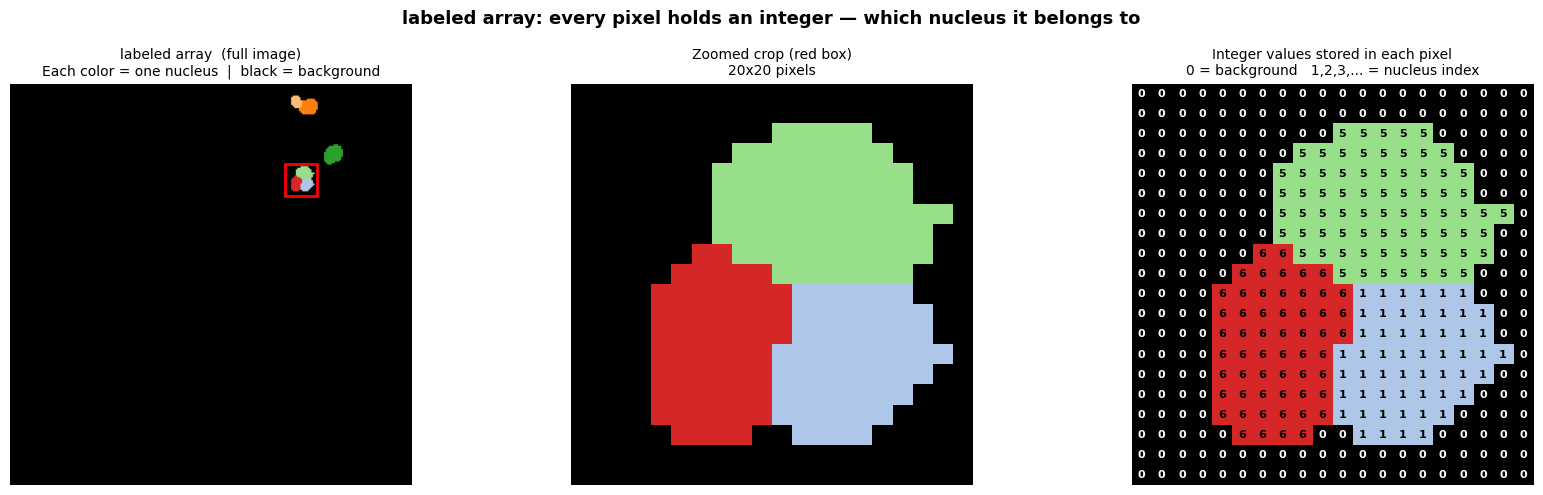

Pixel count per label:
  Background (0) :  65,091 pixels
  Nucleus #1     :      54 pixels  ██
  Nucleus #2     :      96 pixels  ████
  Nucleus #3     :      47 pixels  ██
  Nucleus #4     :     119 pixels  █████
  Nucleus #5     :      73 pixels  ███
  Nucleus #6     :      56 pixels  ██


In [36]:

# ── What does the labeled array actually look like? ────────────────────────
# Pick a small image (few nuclei) so values are easy to read
small_ids = sorted(
    all_ids,
    key=lambda i: len(list((TRAIN_DIR / i / 'masks').glob('*.png')))
)
demo_id    = small_ids[23]
print(f'Image ID      : {demo_id}')

demo_masks = sorted((TRAIN_DIR / demo_id / 'masks').glob('*.png'))
demo_img   = cv2.cvtColor(cv2.imread(
    str(next((TRAIN_DIR / demo_id / 'images').glob('*.png')))
), cv2.COLOR_BGR2RGB)

h_d, w_d = demo_img.shape[:2]
labeled_demo = np.zeros((h_d, w_d), dtype=np.int32)
for i, mp in enumerate(demo_masks):
    m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
    labeled_demo[m > 127] = i + 1   # background=0, nucleus i → integer i+1

n_nuclei = len(demo_masks)
print(f'Image size    : {h_d} x {w_d}')
print(f'Nucleus count : {n_nuclei}')
print(f'labeled shape : {labeled_demo.shape}   dtype: {labeled_demo.dtype}')
print(f'Unique values : {np.unique(labeled_demo).tolist()}')
print(f'  → 0 = background, 1~{n_nuclei} = nucleus index\n')

# --- find a crop that contains a boundary between two adjacent nuclei ---
# look for a row where at least two different nucleus labels appear
border_rows = [
    r for r in range(h_d)
    if len(set(labeled_demo[r][labeled_demo[r] > 0])) >= 2
]
cy = border_rows[len(border_rows) // 2] if border_rows else h_d // 2

# center the crop on the first nucleus in that row
nuc_cols = np.where(labeled_demo[cy] > 0)[0]
cx = int(nuc_cols.mean()) if len(nuc_cols) else w_d // 2

crop_r = 10
y0, y1 = max(0, cy - crop_r), min(h_d, cy + crop_r)
x0, x1 = max(0, cx - crop_r), min(w_d, cx + crop_r)
crop = labeled_demo[y0:y1, x0:x1]

# --- visualize ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1) full labeled image (color-coded)
cmap_d = matplotlib.colormaps.get_cmap('tab20')
lc_full = cmap_d((labeled_demo % 20) / 20.0).copy()
lc_full[labeled_demo == 0] = [0, 0, 0, 1]
axes[0].imshow(lc_full)
axes[0].set_title(
    f'labeled array  (full image)\n'
    f'Each color = one nucleus  |  black = background', fontsize=10)
axes[0].axis('off')
rect = plt.Rectangle((x0, y0), x1-x0, y1-y0,
                      linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)

# 2) zoomed color view
lc_crop = cmap_d((crop % 20) / 20.0).copy()
lc_crop[crop == 0] = [0, 0, 0, 1]
axes[1].imshow(lc_crop, interpolation='nearest')
axes[1].set_title(f'Zoomed crop (red box)\n{crop.shape[0]}x{crop.shape[1]} pixels', fontsize=10)
axes[1].axis('off')

# 3) actual integer values printed on each pixel
axes[2].imshow(lc_crop, interpolation='nearest')
for row in range(crop.shape[0]):
    for col in range(crop.shape[1]):
        val = crop[row, col]
        txt_color = 'white' if val == 0 else 'black'
        axes[2].text(col, row, str(val), ha='center', va='center',
                     fontsize=8, color=txt_color, fontweight='bold')
axes[2].set_title(
    'Integer values stored in each pixel\n'
    '0 = background   1,2,3,... = nucleus index', fontsize=10)
axes[2].axis('off')

plt.suptitle(
    'labeled array: every pixel holds an integer — which nucleus it belongs to',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# print per-nucleus pixel count
print('Pixel count per label:')
print(f'  Background (0) : {(labeled_demo == 0).sum():>7,} pixels')
for nid in range(1, min(n_nuclei + 1, 11)):
    cnt = (labeled_demo == nid).sum()
    bar = '█' * (cnt // 20)
    print(f'  Nucleus #{nid:<3}   : {cnt:>7,} pixels  {bar}')
if n_nuclei > 10:
    print(f'  ... and {n_nuclei - 10} more nuclei')


## 2. `create_body_border_mask` — Step-by-step visualization

In [18]:
# Pick an image with many nuclei (more touching nuclei = more interesting borders)
counts = [(len(list((TRAIN_DIR / i / 'masks').glob('*.png'))), i) for i in all_ids[:80]]
counts.sort(reverse=True)
sample_id  = counts[2][1]

img_path   = next((TRAIN_DIR / sample_id / 'images').glob('*.png'))
mask_paths = sorted((TRAIN_DIR / sample_id / 'masks').glob('*.png'))

img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
print(f'Image ID    : {sample_id[:20]}...')
print(f'Nucleus count: {len(mask_paths)}')
print(f'Image size  : {img.shape[0]} x {img.shape[1]}')

Image ID    : 150b0ffa318c87b31d78...
Nucleus count: 198
Image size  : 520 x 696


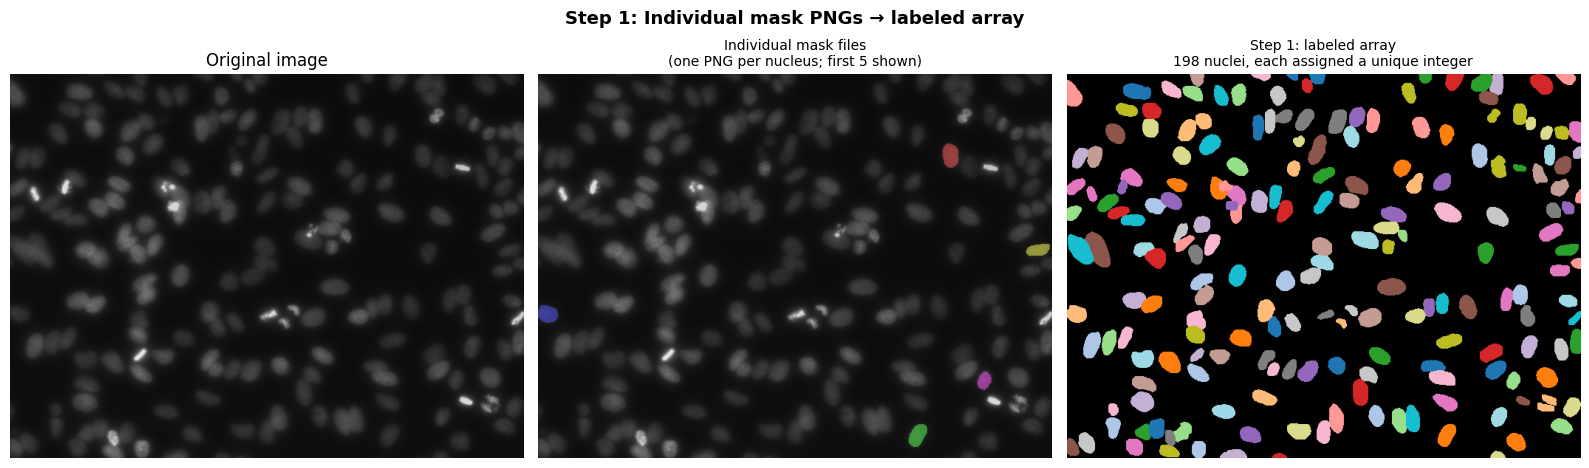

In [19]:
# ── Step 1: Individual mask PNGs → labeled array ─────────────────────────
h, w = img.shape[:2]
labeled = np.zeros((h, w), dtype=np.int32)
for i, mp in enumerate(mask_paths):
    m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
    labeled[m > 127] = i + 1

body_bin = (labeled > 0)

cmap = matplotlib.colormaps.get_cmap('tab20')
labeled_color = cmap((labeled % 20) / 20.0)
labeled_color[labeled == 0] = [0, 0, 0, 1]

# Show first 5 individual masks as a color overlay
palette = [(255, 80, 80), (80, 255, 80), (80, 80, 255), (255, 255, 80), (255, 80, 255)]
overlay = img.astype(np.float32).copy()
for i, mp in enumerate(mask_paths[:5]):
    m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
    px = m > 127
    color = palette[i % len(palette)]
    for c in range(3):
        overlay[px, c] = overlay[px, c] * 0.5 + color[c] * 0.5

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img)
axes[0].set_title('Original image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(overlay.astype(np.uint8))
axes[1].set_title(f'Individual mask files\n(one PNG per nucleus; first 5 shown)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(labeled_color)
axes[2].set_title(f'Step 1: labeled array\n{len(mask_paths)} nuclei, each assigned a unique integer', fontsize=10)
axes[2].axis('off')

plt.suptitle('Step 1: Individual mask PNGs → labeled array', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

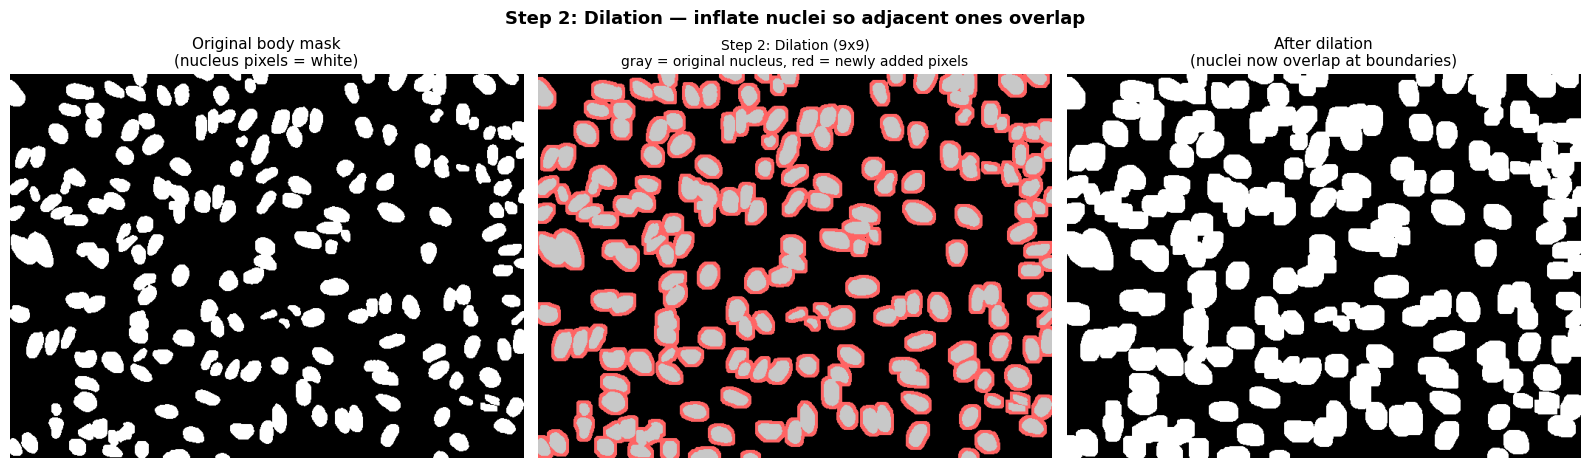

In [20]:
# ── Step 2: Dilation ──────────────────────────────────────────────────────
dilated = dilation(body_bin, footprint_rectangle((9, 9)))

diff = dilated.astype(int) - body_bin.astype(int)
vis  = np.zeros((h, w, 3), dtype=np.uint8)
vis[body_bin]  = [200, 200, 200]
vis[diff == 1] = [255, 100, 100]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(body_bin, cmap='gray')
axes[0].set_title('Original body mask\n(nucleus pixels = white)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(vis)
axes[1].set_title('Step 2: Dilation (9x9)\ngray = original nucleus, red = newly added pixels', fontsize=10)
axes[1].axis('off')

axes[2].imshow(dilated, cmap='gray')
axes[2].set_title('After dilation\n(nuclei now overlap at boundaries)', fontsize=11)
axes[2].axis('off')

plt.suptitle('Step 2: Dilation — inflate nuclei so adjacent ones overlap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

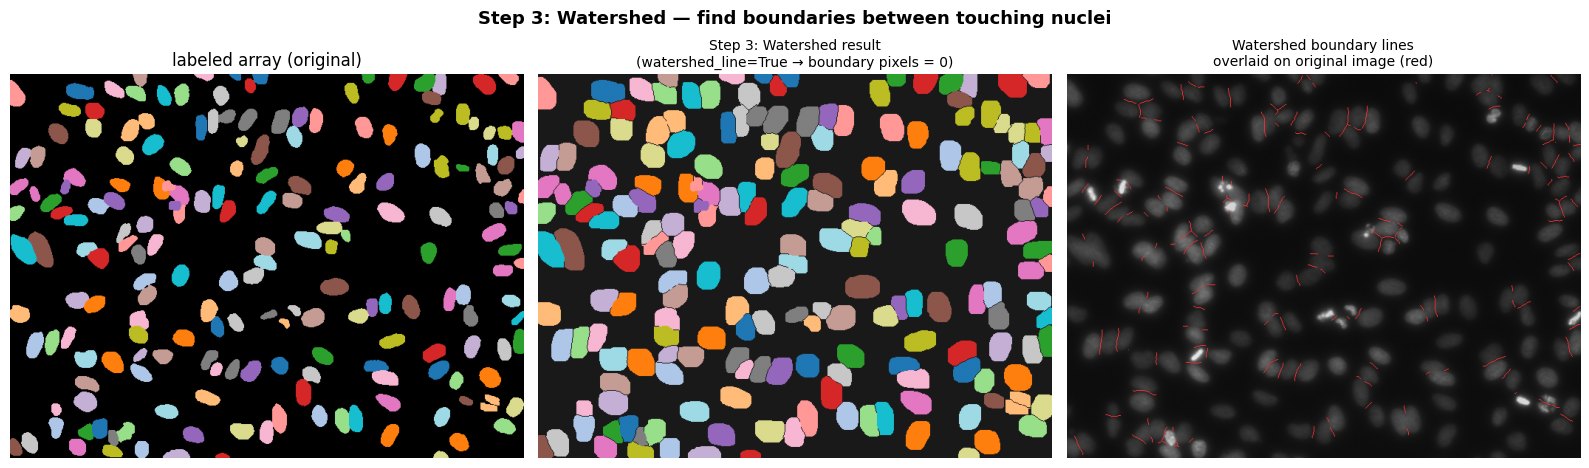

In [21]:
# ── Step 3: Watershed ─────────────────────────────────────────────────────
ws = watershed(dilated, labeled, mask=dilated, watershed_line=True)

ws_color = cmap((ws % 20) / 20.0)
ws_color[ws == 0] = [0.1, 0.1, 0.1, 1]

ws_boundary = (ws == 0) & dilated
vis2 = img.copy()
vis2[ws_boundary] = [255, 50, 50]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(labeled_color)
axes[0].set_title('labeled array (original)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(ws_color)
axes[1].set_title('Step 3: Watershed result\n(watershed_line=True → boundary pixels = 0)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(vis2)
axes[2].set_title('Watershed boundary lines\noverlaid on original image (red)', fontsize=10)
axes[2].axis('off')

plt.suptitle('Step 3: Watershed — find boundaries between touching nuclei', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

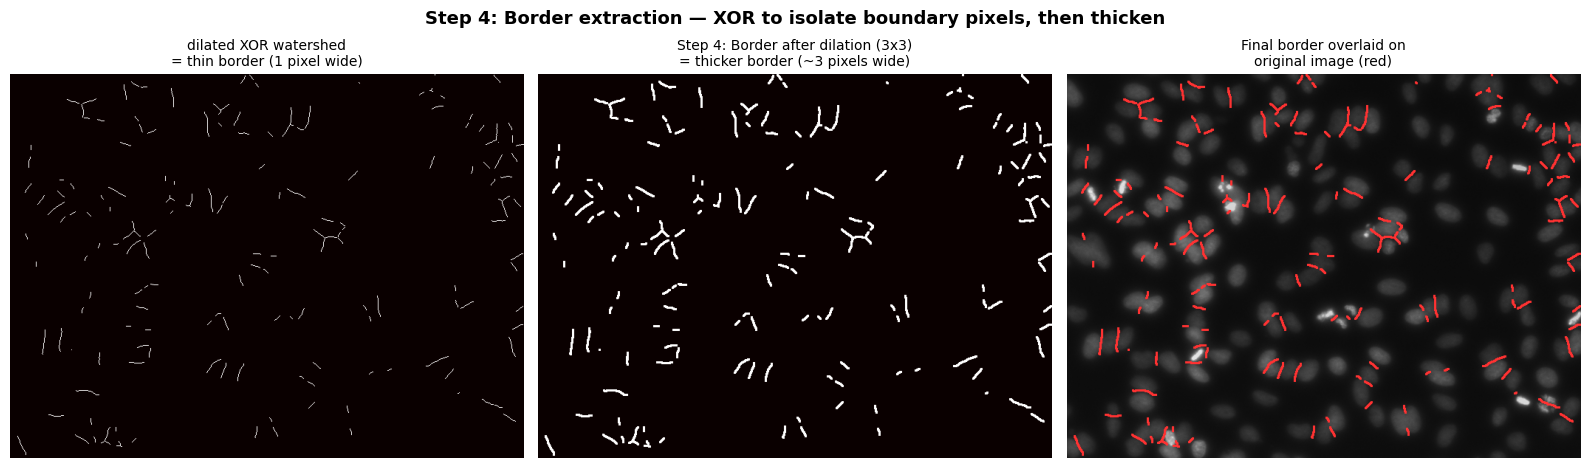

In [22]:
# ── Step 4: Border extraction + dilation ─────────────────────────────────
border_thin = (dilated ^ (ws > 0))
border      = dilation(border_thin, footprint_rectangle((3, 3)))

vis3 = img.copy()
vis3[border] = [255, 50, 50]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(border_thin, cmap='hot')
axes[0].set_title('dilated XOR watershed\n= thin border (1 pixel wide)', fontsize=10)
axes[0].axis('off')

axes[1].imshow(border, cmap='hot')
axes[1].set_title('Step 4: Border after dilation (3x3)\n= thicker border (~3 pixels wide)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(vis3)
axes[2].set_title('Final border overlaid on\noriginal image (red)', fontsize=10)
axes[2].axis('off')

plt.suptitle('Step 4: Border extraction — XOR to isolate boundary pixels, then thicken', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

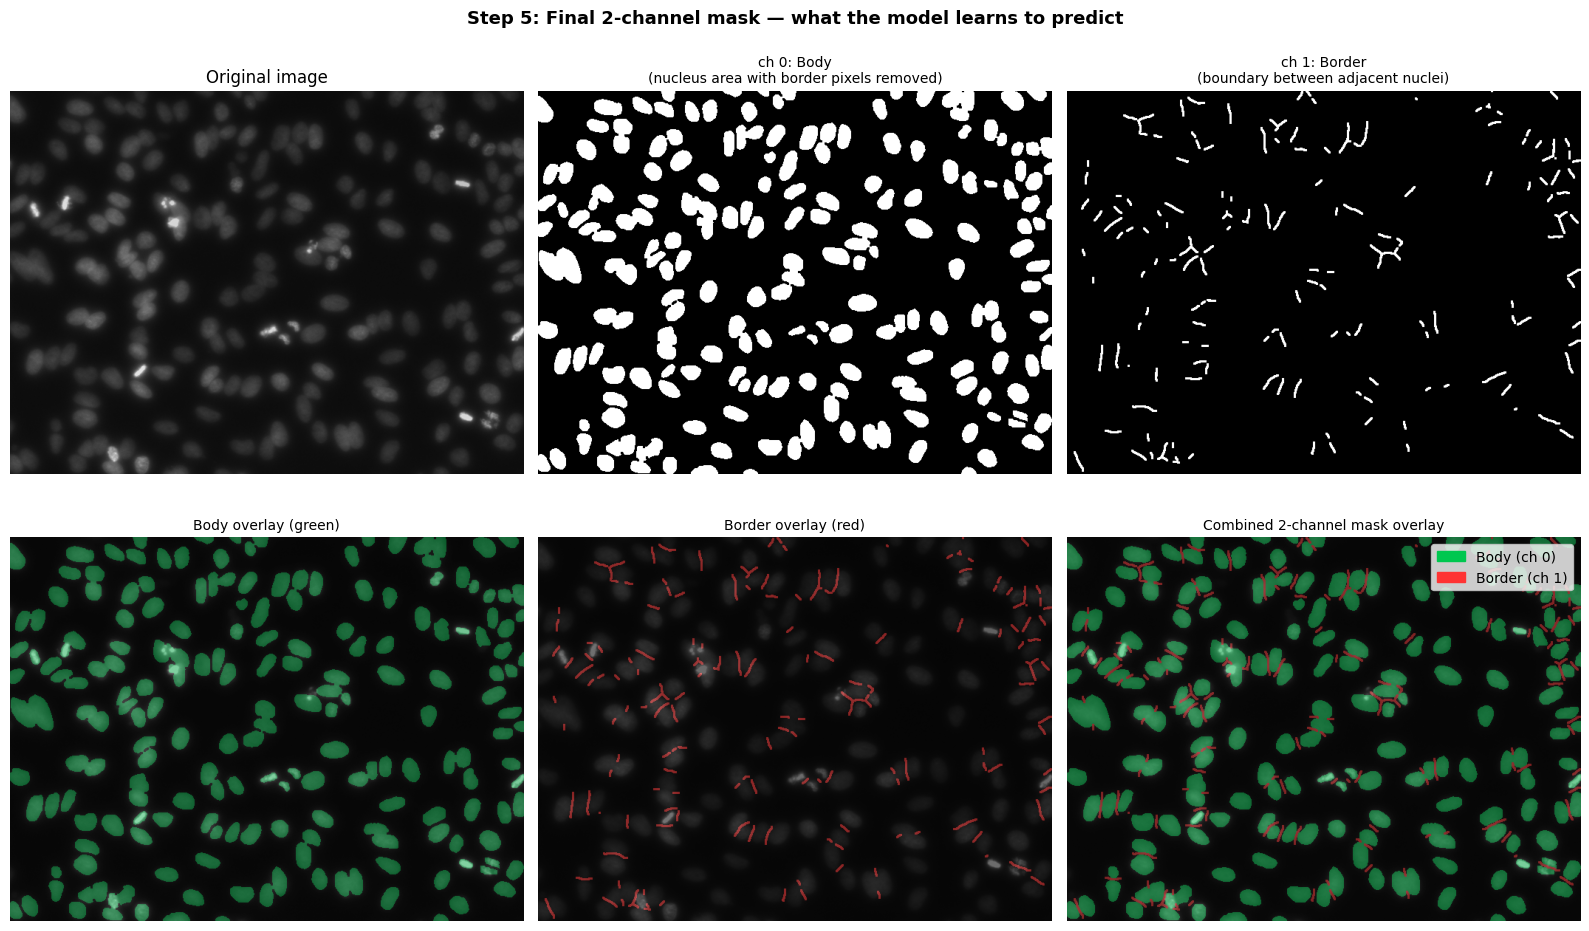

Image size     : 520 x 696 = 361,920 pixels
Body pixels    : 86,288  (23.8%)
Border pixels  : 9,066  (2.5%)
Background     : 266,566  (73.7%)


In [23]:
# ── Step 5: Final 2-channel mask ──────────────────────────────────────────
body = body_bin.copy().astype(np.uint8)
body[border] = 0

body_overlay   = np.zeros((h, w, 3), dtype=np.float32)
border_overlay = np.zeros((h, w, 3), dtype=np.float32)
body_overlay[body > 0]     = [0,   200, 80]
border_overlay[border > 0] = [255,  50, 50]

combined = np.zeros((h, w, 3), dtype=np.float32)
combined[body > 0]   = [0,   200, 80]
combined[border > 0] = [255,  50, 50]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(img)
axes[0, 0].set_title('Original image', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(body, cmap='gray')
axes[0, 1].set_title('ch 0: Body\n(nucleus area with border pixels removed)', fontsize=10)
axes[0, 1].axis('off')

axes[0, 2].imshow(border, cmap='gray')
axes[0, 2].set_title('ch 1: Border\n(boundary between adjacent nuclei)', fontsize=10)
axes[0, 2].axis('off')

axes[1, 0].imshow(img)
axes[1, 0].imshow(body_overlay.astype(np.uint8), alpha=0.4)
axes[1, 0].set_title('Body overlay (green)', fontsize=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(img)
axes[1, 1].imshow(border_overlay.astype(np.uint8), alpha=0.5)
axes[1, 1].set_title('Border overlay (red)', fontsize=10)
axes[1, 1].axis('off')

axes[1, 2].imshow(img)
axes[1, 2].imshow(combined.astype(np.uint8), alpha=0.45)
green_patch = mpatches.Patch(color=(0, 0.78, 0.31), label='Body (ch 0)')
red_patch   = mpatches.Patch(color=(1,  0.20, 0.20), label='Border (ch 1)')
axes[1, 2].legend(handles=[green_patch, red_patch], loc='upper right', fontsize=10)
axes[1, 2].set_title('Combined 2-channel mask overlay', fontsize=10)
axes[1, 2].axis('off')

plt.suptitle('Step 5: Final 2-channel mask — what the model learns to predict', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total_px  = h * w
body_px   = int(body.sum())
border_px = int(border.sum())
bg_px     = total_px - body_px - border_px
print(f'Image size     : {h} x {w} = {total_px:,} pixels')
print(f'Body pixels    : {body_px:,}  ({body_px/total_px*100:.1f}%)')
print(f'Border pixels  : {border_px:,}  ({border_px/total_px*100:.1f}%)')
print(f'Background     : {bg_px:,}  ({bg_px/total_px*100:.1f}%)')

## 3. Multiple random samples at a glance

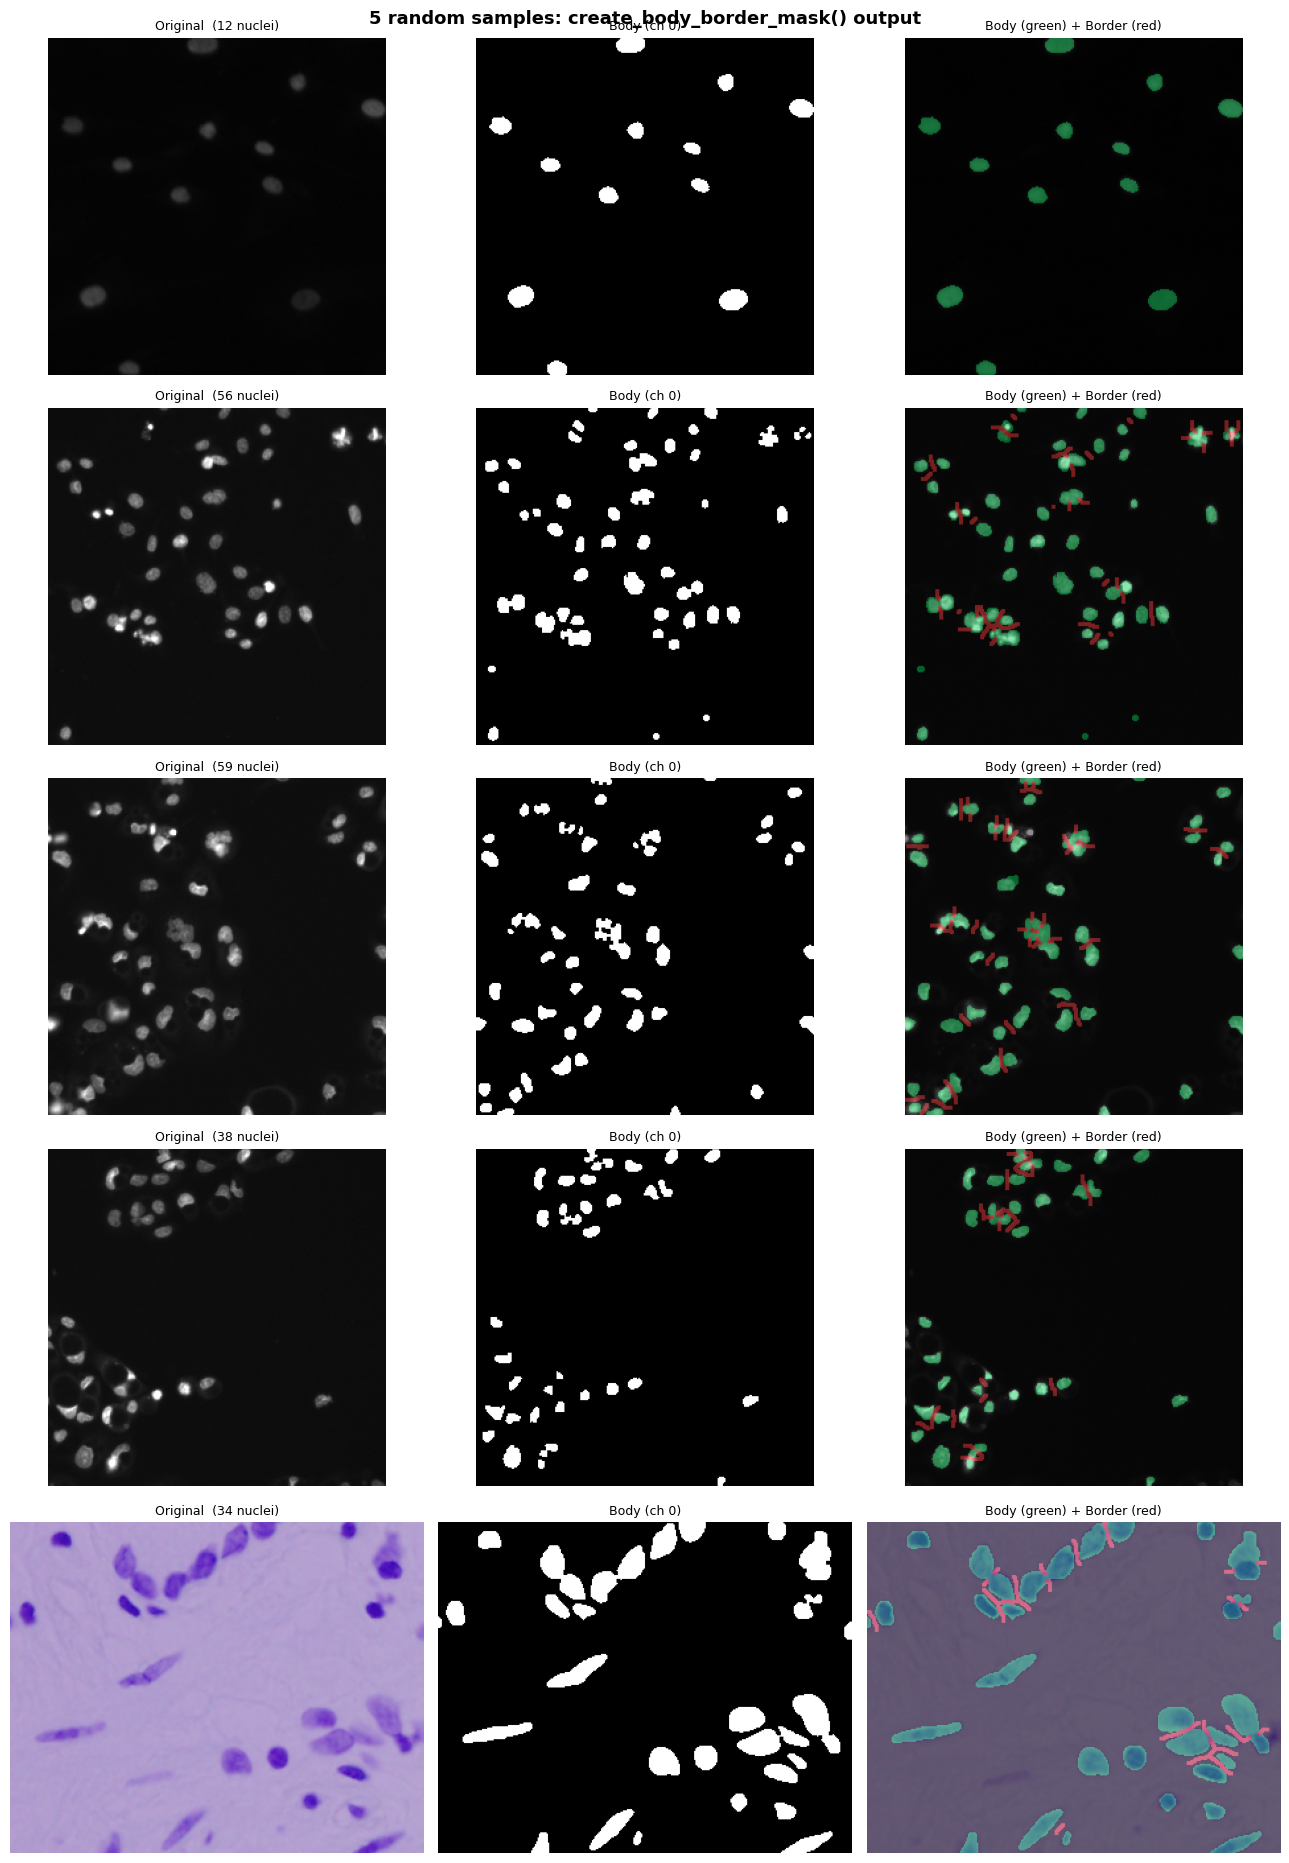

In [24]:
from nuclei_seg.datasets.dsb import create_body_border_mask

sample_ids = random.sample(all_ids, 5)

fig, axes = plt.subplots(5, 3, figsize=(13, 19))

for row, sid in enumerate(sample_ids):
    img_path_s   = next((TRAIN_DIR / sid / 'images').glob('*.png'))
    mask_paths_s = sorted((TRAIN_DIR / sid / 'masks').glob('*.png'))

    img_s    = cv2.cvtColor(cv2.imread(str(img_path_s)), cv2.COLOR_BGR2RGB)
    mask_s   = create_body_border_mask(mask_paths_s)  # (H, W, 2)
    body_s   = mask_s[:, :, 0]
    border_s = mask_s[:, :, 1]

    combined_s = np.zeros((*img_s.shape[:2], 3), dtype=np.float32)
    combined_s[body_s   > 0] = [0,   200, 80]
    combined_s[border_s > 0] = [255,  50, 50]

    axes[row, 0].imshow(img_s)
    axes[row, 0].set_title(f'Original  ({len(mask_paths_s)} nuclei)', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(body_s, cmap='gray')
    axes[row, 1].set_title('Body (ch 0)', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(img_s)
    axes[row, 2].imshow(combined_s.astype(np.uint8), alpha=0.45)
    axes[row, 2].set_title('Body (green) + Border (red)', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle('5 random samples: create_body_border_mask() output', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()